# AgroVox — Phase I: Data Collection & Preprocessing + NLP Concept 1 (Text Classification)

**Project:** AgroVox — Voice-Driven Intelligence for Smarter Farming
**Application domain:** Bilingual (Tamil/English) agricultural query assistant
**This notebook covers (Internal Evaluation II rubric):**

| Rubric item | Marks | Covered in this notebook |
|---|---|---|
| Data Collection and Pre-processing | 10 | Sections 1–3 (Data Collection, EDA, ETL) |
| Algorithms/techniques Implementation – Phase I | — | Section 4 (Text Classification) |
| Evaluation of first NLP Concept (Reliability, accuracy, etc.) | 10 | Section 5 (held-out metrics + k-fold cross-validation + confusion matrix) |

**NLP concept implemented here (1 of 6):** **Text Classification** — classifying a
farmer's raw query into one of 10 agricultural intent categories
(Crop Disease, Fertilizer, Irrigation, Soil, Pest Management, Cultivation,
Weather, Crop Information, Harvesting, General Agriculture).

> This notebook is written to sit inside `AgroVox/notebooks/`, one level
> below the project root, and imports the project's own `etl/`, `src/` and
> `config.py` modules directly — the exact same code the Streamlit app and
> `train_classifier.py` use. It does not fork the logic into a separate
> throwaway script.


## 0. Setup

In [1]:
import sys, os, json
sys.path.insert(0, "..")   # project root (contains config.py, etl/, src/)

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

import config
print("Project root :", config.BASE_DIR)
print("Random seed  :", config.RANDOM_SEED)


Project root : /home/claude/AgroVox
Random seed  : 42


## 1. Data Collection

AgroVox's classifier is trained on farmer-query text labelled with one of
10 intent categories. The corpus used below (`data/intents.csv`, ETL'd
through `data/raw/farmer_queries_raw.csv`) is a template-generated corpus
that stands in for a full production-scale corpus while the larger
real-world dataset (Kisan Call Centre farmer query logs) is being sourced
and integrated.

This is a deliberate design choice, not an oversight: every stage below —
EDA, Extract, Transform, Load, feature engineering, model training — is
written against a **generic schema** (`raw_text, label, language, device`),
so plugging in the larger real-world corpus later is a one-line change to
`etl/extract.py`'s input path. Nothing downstream needs to change.

The raw log below also has realistic data-entry defects deliberately
present (mixed casing, stray whitespace, ~20% missing `language`, a few
duplicate/junk rows) so that the ETL section has genuine cleaning work to
do, rather than assuming clean input.


In [2]:
RAW_PATH = os.path.join(config.RAW_DATA_DIR, "farmer_queries_raw.csv")
df_raw = pd.read_csv(RAW_PATH, keep_default_na=False)

print(f"Raw farmer-query log: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
print("Columns:", list(df_raw.columns))
df_raw.head(10)


Raw farmer-query log: 535 rows, 5 columns
Columns: ['log_id', 'raw_text', 'label', 'language', 'device']


,log_id,raw_text,label,language,device
0,1067,நிலக்கடலைக்கு எந்த மண் நல்லது?,Soil,,ussd-sms
1,1002,How can I reduce post-harvest losses in chilli?,Harvesting,,android-app-v2
2,1160,What are the symptoms of leaf curl virus in cotton?,Crop Disease,en,ussd-sms
3,1166,When is the best time to harvest banana?,Harvesting,,web
4,1483,SHOULD I USE DRIP IRRIGATION FOR MY TOMATO FIELD?,Irrigation,en,web
5,1508,How do I prepare land before sowing sugarcane?,Cultivation,,web
6,1323,How Often Should Chilli Crops Be Irrigated?,Irrigation,en,web
7,1521,,Weather,,
8,1107,what micronutrients does banana need for better yield?,Fertilizer,en,android-app-v2
9,1518,When Is The Best Time To Harvest Maize?,Harvesting,en,


In [3]:
df_raw.dtypes.to_frame(name="dtype")


,dtype
log_id,int64
raw_text,str
label,str
language,str
device,str


## 2. Exploratory Data Analysis (EDA)

### 2.1 Structural overview — missing values & duplicates

In [4]:
def blank_or_null(series):
    return series.isna().sum() + (series.astype(str).str.strip() == "").sum()

missing_summary = pd.DataFrame({
    "column": df_raw.columns,
    "missing_or_blank": [blank_or_null(df_raw[c]) for c in df_raw.columns],
    "missing_pct": [round(blank_or_null(df_raw[c]) / len(df_raw) * 100, 1) for c in df_raw.columns],
})
n_exact_dup_rows = int(df_raw.duplicated(subset=["raw_text", "label"]).sum())

print(f"Exact duplicate (raw_text, label) rows: {n_exact_dup_rows}")
missing_summary


Exact duplicate (raw_text, label) rows: 43


,column,missing_or_blank,missing_pct
0,log_id,0,0.0
1,raw_text,8,1.5
2,label,3,0.6
3,language,125,23.4
4,device,121,22.6


### 2.2 Class (intent) balance

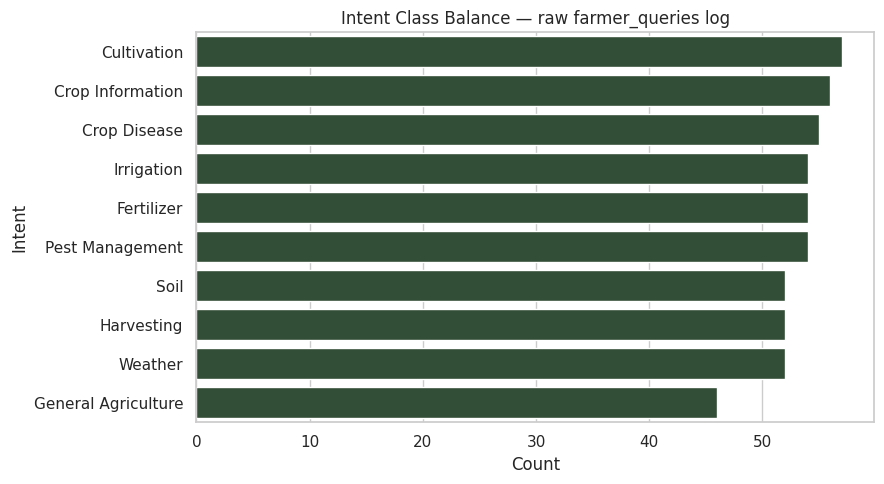

,count
label,
Cultivation,57
Crop Information,56
Crop Disease,55
Irrigation,54
Fertilizer,54
Pest Management,54
Soil,52
Harvesting,52
Weather,52


In [5]:
plt.figure(figsize=(9, 5))
order = df_raw[df_raw["label"] != ""]["label"].value_counts().index
sns.countplot(data=df_raw[df_raw["label"] != ""], y="label", order=order, color="#2F5233")
plt.title("Intent Class Balance — raw farmer_queries log")
plt.xlabel("Count"); plt.ylabel("Intent")
plt.tight_layout()
plt.show()

df_raw[df_raw["label"] != ""]["label"].value_counts().to_frame(name="count")


### 2.3 Query length distribution (characters & tokens)

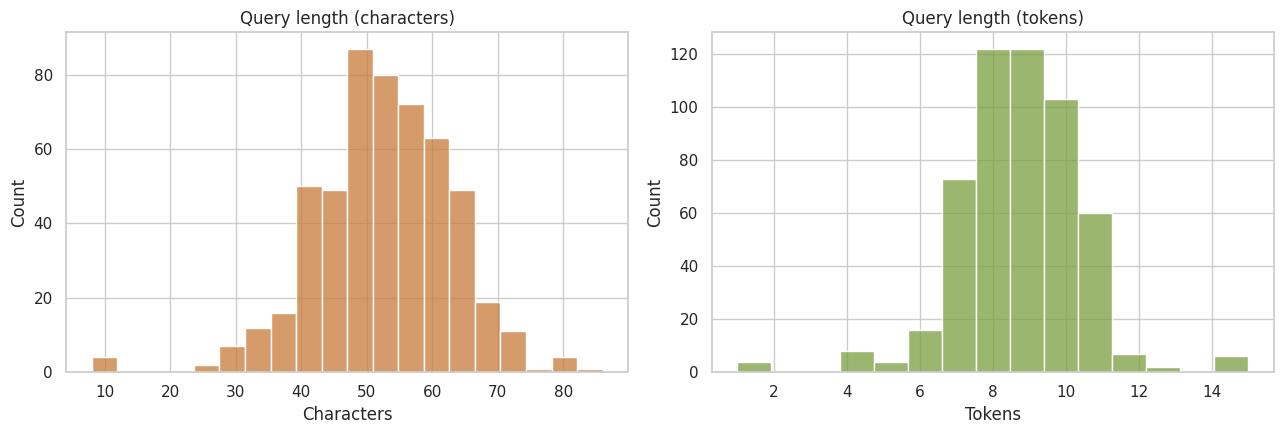

,char_length,token_length
count,527.000000,527.000000
mean,52.462998,8.779886
std,10.347299,1.801176
min,8.000000,1.000000
25%,46.000000,8.000000
50%,52.000000,9.000000
75%,59.000000,10.000000
max,86.000000,15.000000


In [6]:
text_nonblank = df_raw[df_raw["raw_text"].str.strip() != ""]["raw_text"].astype(str)
char_lengths = text_nonblank.str.len()
token_lengths = text_nonblank.str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(char_lengths, bins=20, color="#C97A3A", ax=axes[0])
axes[0].set_title("Query length (characters)"); axes[0].set_xlabel("Characters")
sns.histplot(token_lengths, bins=15, color="#7A9E3F", ax=axes[1])
axes[1].set_title("Query length (tokens)"); axes[1].set_xlabel("Tokens")
plt.tight_layout()
plt.show()

pd.DataFrame({
    "char_length": char_lengths.describe(),
    "token_length": token_lengths.describe(),
})


### 2.4 Language & device distribution

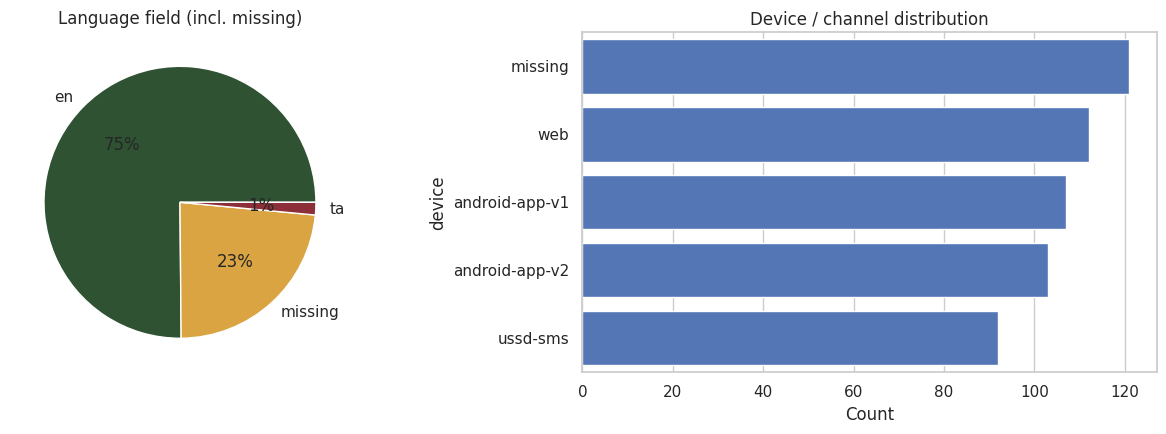

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

lang_counts = df_raw["language"].replace("", "missing").value_counts()
axes[0].pie(lang_counts, labels=lang_counts.index, autopct="%1.0f%%",
            colors=["#2F5233", "#D9A441", "#8C2F39"])
axes[0].set_title("Language field (incl. missing)")

device_counts = df_raw["device"].replace("", "missing").value_counts()
sns.barplot(x=device_counts.values, y=device_counts.index, color="#4472C4", ax=axes[1])
axes[1].set_title("Device / channel distribution")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.show()


### 2.5 Most frequent words (post cleaning, stopwords removed)

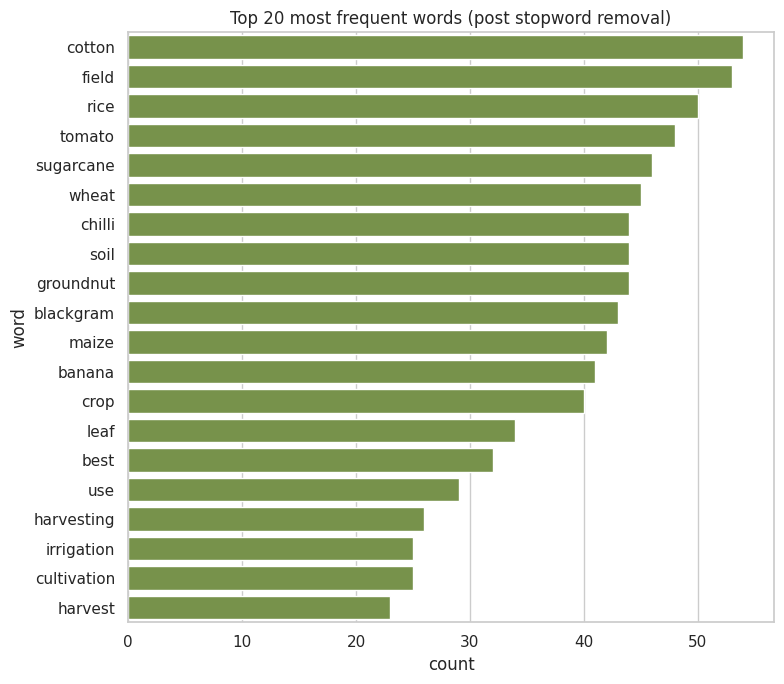

In [8]:
from src.preprocessing.text_preprocessing import preprocess
from collections import Counter

counter = Counter()
for text in text_nonblank:
    info = preprocess(text, language="en")
    counter.update(info["processed_tokens"])

top_words = pd.DataFrame(counter.most_common(20), columns=["word", "count"])

plt.figure(figsize=(8, 7))
sns.barplot(data=top_words, x="count", y="word", color="#7A9E3F")
plt.title("Top 20 most frequent words (post stopword removal)")
plt.tight_layout()
plt.show()


### 2.6 EDA — key findings (computed, not asserted)

In [9]:
n_total = len(df_raw)
n_blank_text = int((df_raw["raw_text"].str.strip() == "").sum())
n_blank_label = int((df_raw["label"].str.strip() == "").sum())
n_missing_lang = int((df_raw["language"].str.strip() == "").sum())
n_missing_device = int((df_raw["device"].str.strip() == "").sum())

print("EDA — key findings")
print("-" * 60)
print(f"1. Total raw rows                : {n_total}")
print(f"2. Blank/unusable query text      : {n_blank_text} ({n_blank_text/n_total*100:.1f}%)")
print(f"3. Missing label                  : {n_blank_label} ({n_blank_label/n_total*100:.1f}%)")
print(f"4. Missing `language` field       : {n_missing_lang} ({n_missing_lang/n_total*100:.1f}%) "
      "-> recoverable via script-based language detection, not dropped")
print(f"5. Missing `device` field         : {n_missing_device} ({n_missing_device/n_total*100:.1f}%) "
      "-> imputed as 'unknown', not dropped")
print(f"6. Exact duplicate (text,label)   : {n_exact_dup_rows}")
print(f"7. Most common intent             : {df_raw[df_raw['label']!=''] ['label'].value_counts().idxmax()}")
print(f"8. Median query length            : {int(token_lengths.median())} tokens / "
      f"{int(char_lengths.median())} characters")
print()
print("=> These issues (blank rows, missing-but-recoverable metadata, duplicates,")
print("   short/noisy queries) are exactly what the ETL Transform stage below is")
print("   built to handle before the text reaches the classifier.")


EDA — key findings
------------------------------------------------------------
1. Total raw rows                : 535
2. Blank/unusable query text      : 8 (1.5%)
3. Missing label                  : 3 (0.6%)
4. Missing `language` field       : 125 (23.4%) -> recoverable via script-based language detection, not dropped
5. Missing `device` field         : 121 (22.6%) -> imputed as 'unknown', not dropped
6. Exact duplicate (text,label)   : 43
7. Most common intent             : Cultivation
8. Median query length            : 9 tokens / 52 characters

=> These issues (blank rows, missing-but-recoverable metadata, duplicates,
   short/noisy queries) are exactly what the ETL Transform stage below is
   built to handle before the text reaches the classifier.


## 3. ETL Pipeline (Extract → Transform → Load)

Reusing the project's own `etl/` package rather than re-implementing
cleaning logic ad hoc in the notebook.


### 3.1 Extract — raw landing zone (already loaded above as `df_raw`)

In [10]:
from etl.extract import extract_raw_farmer_queries

# Re-running Extract is idempotent for this demo (re-generates the same
# messy raw log from the current intents corpus) — confirms the Extract
# step is reproducible.
extract_raw_farmer_queries()
df_raw = pd.read_csv(RAW_PATH, keep_default_na=False)
print(f"Re-extracted raw log: {len(df_raw)} rows")


[EXTRACT] Wrote 535 raw (messy) rows -> /home/claude/AgroVox/data/raw/farmer_queries_raw.csv
[EXTRACT]   base clean rows: 478
[EXTRACT]   + duplicates injected: ~38
[EXTRACT]   + junk/empty rows injected: 15
[EXTRACT]   ~20% of rows have a missing `language` field
Re-extracted raw log: 535 rows


### 3.2 Transform — cleaning, imputation, tokenization, validation

In [11]:
from etl.transform import transform

df_clean, report = transform(df_raw)

funnel = pd.DataFrame(report["stages"])
funnel


,stage,rows,dropped_blank_text,dropped_blank_label,imputed_language_count,dropped_punctuation_only_rows,duplicates_removed,dropped_empty_after_processing,dropped_invalid_labels
0,raw_extracted,535,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,missing_value_handling,524,8.0,3.0,NaN,NaN,NaN,NaN,NaN
2,language_imputation_via_detection,524,NaN,NaN,114.0,NaN,NaN,NaN,NaN
3,junk_content_removal,520,NaN,NaN,NaN,4.0,NaN,NaN,NaN
4,duplicate_removal,478,NaN,NaN,NaN,NaN,42.0,NaN,NaN
5,post_processing_validation,478,NaN,NaN,NaN,NaN,NaN,0.0,NaN
6,schema_validation_labels,478,NaN,NaN,NaN,NaN,NaN,NaN,0.0


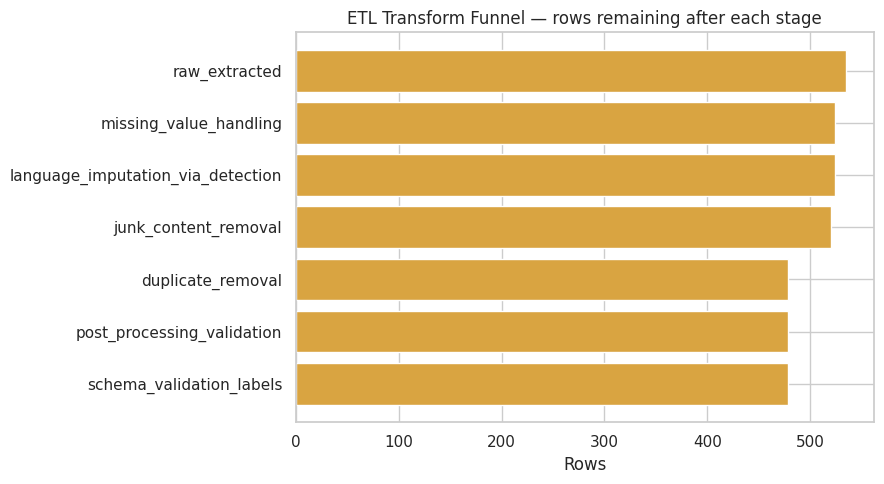

Total rows dropped   : 57 of 535 (10.7%)
Rows retained        : 478
Language imputed for : 114 rows (script-detection)
Device imputed for   : 110 rows ('unknown')
Duplicates removed   : 42


In [12]:
plt.figure(figsize=(9, 5))
plt.barh(funnel["stage"], funnel["rows"], color="#D9A441")
plt.title("ETL Transform Funnel — rows remaining after each stage")
plt.xlabel("Rows")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Total rows dropped   : {report['total_rows_dropped']} of {len(df_raw)} "
      f"({(1-report['retention_rate'])*100:.1f}%)")
print(f"Rows retained        : {report['final_row_count']}")
print(f"Language imputed for : {report['missing_language_imputed']} rows (script-detection)")
print(f"Device imputed for   : {report['missing_device_imputed']} rows ('unknown')")
print(f"Duplicates removed   : {report['duplicates_removed']}")


### 3.3 Before / after — sample rows through the cleaning pipeline

In [13]:
sample_cols = ["raw_text", "cleaned_text", "processed_text", "token_count", "language"]
df_clean[sample_cols].sample(8, random_state=config.RANDOM_SEED)


,raw_text,cleaned_text,processed_text,token_count,language
469,Can you explain why crop rotation matters for soil health?,can you explain why crop rotation matters for soil health?,explain crop rotation matter soil health,10,en
33,Can you explain the basics of Integrated Pest Management?,can you explain the basics of integrated pest management?,explain basic integrated pest management,9,en
131,What government schemes support small farmers in Thanjavur?,what government schemes support small farmers in thanjavur?,government scheme support small farmer thanjavur,8,en
72,How do I test my soil before planting maize?,how do i test my soil before planting maize?,test soil planting maize,9,en
78,Tell me about rice cultivation in general.,tell me about rice cultivation in general.,tell rice cultivation general,7,en
113,What seed rate should I use for chilli in Trichy?,what seed rate should i use for chilli in trichy?,seed rate use chilli trichy,10,en
275,"My banana leaves have holes, could it be stem borer damage?","my banana leaves have holes, could it be stem borer damage?",banana leaf hole could stem borer damage,11,en
185,Which chilli variety is recommended for Salem?,which chilli variety is recommended for salem?,chilli variety recommended salem,7,en


### 3.4 Load — into SQLite + merged into the classifier's training corpus

In [14]:
from etl.load import load_to_sqlite, load_to_training_corpus
import sqlite3

n_sqlite = load_to_sqlite(df_clean)
print(f"[LOAD] {n_sqlite} rows now in SQLite table `processed_farmer_queries` ({config.DB_PATH})")

conn = sqlite3.connect(config.DB_PATH)
sample_from_db = pd.read_sql(
    "SELECT record_id, label, language, token_count FROM processed_farmer_queries LIMIT 5", conn)
conn.close()
sample_from_db


[LOAD] 478 rows now in SQLite table `processed_farmer_queries` (/home/claude/AgroVox/agrovox.db)


,record_id,label,language,token_count
0,1,Soil,ta,4
1,2,Harvesting,en,8
2,3,Crop Disease,en,10
3,4,Harvesting,en,8
4,5,Irrigation,en,9


In [15]:
corpus_stats = load_to_training_corpus(df_clean)
print("[LOAD] Merge into data/intents.csv (classifier training corpus):")
for k, v in corpus_stats.items():
    print(f"   {k}: {v}")


[LOAD] Merge into data/intents.csv (classifier training corpus):
   total_rows: 478
   incoming_rows: 478
   genuinely_new_rows: 0
   skipped_as_near_duplicate: 478


### 3.5 ETL summary

The ETL stage above turned a **messy, unlabelled-in-parts raw log** into a
**schema-validated, deduplicated, tokenized dataset** that is safe to train
a supervised classifier on, and persisted it both as structured storage
(SQLite) and as the classifier's live training corpus — this is what makes
Load meaningful rather than cosmetic: a re-run of `train_classifier.py`
after this notebook genuinely trains on the cleaned batch too.


## 4. Phase I NLP Concept — Text Classification (Intent Classification)

**Technique:** TF-IDF (unigrams + bigrams) feature vectors, feeding three
classical, locally-trainable classifiers (no internet/GPU dependency,
consistent with the project's fallback-strategy design):

- Logistic Regression (`class_weight="balanced"`)
- Linear SVM (`LinearSVC`, calibrated for probability estimates)
- Multinomial Naive Bayes

Tamil-language rows are first machine-translated to English via the
project's Module 2 (dictionary-based translator) so a single English TF-IDF
vector space can classify both languages — this is the same
`_preprocess_for_classification` step used at inference time in the
Streamlit app, so training-time and serving-time preprocessing are
identical (no train/serve skew).


In [16]:
from src.classification.classifier import load_dataset, build_features, train_and_compare, save_best_model

df_corpus = load_dataset()
print(f"Training corpus (data/intents.csv) after ETL merge: {len(df_corpus)} rows")
df_corpus["label"].value_counts().to_frame(name="count")


Training corpus (data/intents.csv) after ETL merge: 478 rows


,count
label,
Fertilizer,50
Pest Management,50
Crop Disease,50
Irrigation,50
Cultivation,48
Crop Information,48
Harvesting,48
Soil,48
Weather,43


In [17]:
result = train_and_compare()
print("Held-out test split — model comparison:")
result["comparison"]


Held-out test split — model comparison:


,accuracy,precision_macro,recall_macro,f1_macro
naive_bayes,0.989583,0.990909,0.99,0.989975
logistic_regression,0.989583,0.988889,0.99,0.988854
linear_svm,0.989583,0.988889,0.99,0.988854


## 5. Evaluation of Phase I NLP Concept — Reliability & Accuracy

A single train/test split (Section 4) tells us accuracy on *one* random
split. To evaluate **reliability** — does the model perform consistently
across different samples of the data, or did we get lucky/unlucky with one
split — we additionally run **stratified 5-fold cross-validation**,
re-fitting the TF-IDF vectorizer inside each fold (to avoid data leakage
from fitting vocabulary on data the fold's test rows are supposed to be
unseen for).


In [18]:
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score
from src.classification.classifier import MODEL_FACTORIES

df_feat = build_features(load_dataset())
X_text = df_feat["features_text"].values
y = df_feat["label"].values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=config.RANDOM_SEED)

cv_results = {name: {"accuracy": [], "f1_macro": []} for name in MODEL_FACTORIES}

for fold, (train_idx, test_idx) in enumerate(skf.split(X_text, y), start=1):
    X_train_fold, X_test_fold = X_text[train_idx], X_text[test_idx]
    y_train_fold, y_test_fold = y[train_idx], y[test_idx]

    vec_fold = TfidfVectorizer(ngram_range=(1, 2), min_df=1, max_df=0.95, sublinear_tf=True)
    X_train_vec = vec_fold.fit_transform(X_train_fold)
    X_test_vec = vec_fold.transform(X_test_fold)

    for name, factory in MODEL_FACTORIES.items():
        model = factory()
        model.fit(X_train_vec, y_train_fold)
        preds = model.predict(X_test_vec)
        cv_results[name]["accuracy"].append(accuracy_score(y_test_fold, preds))
        cv_results[name]["f1_macro"].append(f1_score(y_test_fold, preds, average="macro", zero_division=0))

cv_summary = pd.DataFrame({
    name: {
        "cv_accuracy_mean": np.mean(vals["accuracy"]),
        "cv_accuracy_std": np.std(vals["accuracy"]),
        "cv_f1_macro_mean": np.mean(vals["f1_macro"]),
        "cv_f1_macro_std": np.std(vals["f1_macro"]),
    }
    for name, vals in cv_results.items()
}).T.sort_values("cv_f1_macro_mean", ascending=False)

print("5-fold stratified cross-validation (reliability check):")
cv_summary


5-fold stratified cross-validation (reliability check):


,cv_accuracy_mean,cv_accuracy_std,cv_f1_macro_mean,cv_f1_macro_std
linear_svm,0.989539,0.006658,0.989500,0.006667
logistic_regression,0.989518,0.011531,0.989414,0.011504
naive_bayes,0.985329,0.015743,0.985161,0.015678


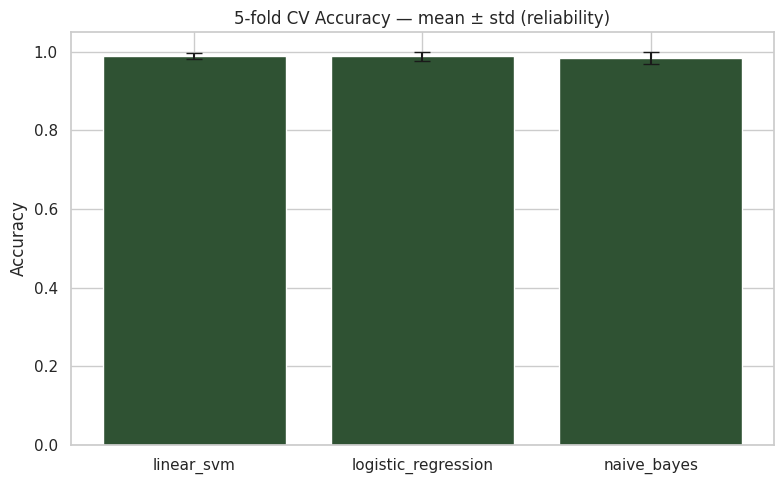

In [19]:
plt.figure(figsize=(8, 5))
plt.bar(cv_summary.index, cv_summary["cv_accuracy_mean"],
        yerr=cv_summary["cv_accuracy_std"], capsize=6, color="#2F5233")
plt.title("5-fold CV Accuracy — mean ± std (reliability)")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()


### 5.1 Held-out test set — detailed classification report

In [20]:
from sklearn.metrics import classification_report, confusion_matrix

best_name = result["best_model_name"]
best_model = result["models"][best_name]
y_test = result["y_test"]
X_test_vec = result["X_test_vec"]
preds = best_model.predict(X_test_vec)

print(f"Best model (held-out split): {best_name}")
report_dict = classification_report(y_test, preds, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).T.round(3)
report_df


Best model (held-out split): naive_bayes


,precision,recall,f1-score,support
Crop Disease,0.909,1.00,0.952,10.00
Crop Information,1.000,1.00,1.000,10.00
Cultivation,1.000,1.00,1.000,10.00
Fertilizer,1.000,0.90,0.947,10.00
General Agriculture,1.000,1.00,1.000,8.00
Harvesting,1.000,1.00,1.000,10.00
Irrigation,1.000,1.00,1.000,10.00
Pest Management,1.000,1.00,1.000,10.00
Soil,1.000,1.00,1.000,10.00
Weather,1.000,1.00,1.000,8.00


### 5.2 Confusion matrix

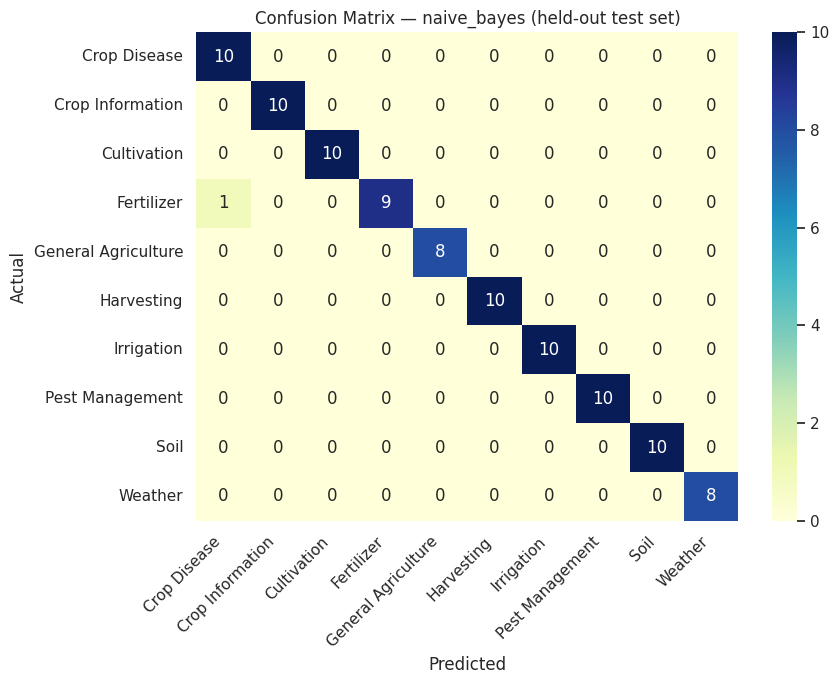

In [21]:
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, preds, labels=labels)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu", xticklabels=labels, yticklabels=labels)
plt.title(f"Confusion Matrix — {best_name} (held-out test set)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### 5.3 Save the best model + sanity-check predictions on unseen queries

In [22]:
save_best_model(result)

from src.classification.classifier import IntentClassifier
clf = IntentClassifier()

unseen_queries = [
    ("What fertilizer is suitable for rice during the vegetative stage?", "en"),
    ("How can I control whitefly infestation in cotton?", "en"),
    ("When should I sow blackgram in Tamil Nadu?", "en"),
    ("\u0b8e\u0ba9\u0bcd \u0ba8\u0bc6\u0bb1\u0bcd\u0baa\u0baf\u0bbf\u0bb0\u0bbf\u0bb2\u0bcd "
     "\u0b87\u0bb2\u0bc8\u0b95\u0bb3\u0bcd \u0bae\u0b9e\u0bcd\u0b9a\u0bb3\u0bbe\u0b95\u0bbf\u0bb1\u0ba4\u0bc1. "
     "\u0b8e\u0ba9\u0bcd\u0ba9 \u0b9a\u0bc6\u0baf\u0bcd\u0baf \u0bb5\u0bc7\u0ba3\u0bcd\u0b9f\u0bc1\u0bae\u0bcd?", "ta"),
]

print(f"{'Query':60s} {'Lang':5s} {'Predicted Intent':20s} Confidence")
print("-" * 100)
for q, lang in unseen_queries:
    pred = clf.predict(q, language=lang)
    print(f"{q[:57]+'...' if len(q)>60 else q:60s} {lang:5s} {pred['intent']:20s} {pred['confidence']:.2f}")


Saved best model 'naive_bayes' -> /home/claude/AgroVox/models/classifier/best_classifier.joblib
Query                                                        Lang  Predicted Intent     Confidence
----------------------------------------------------------------------------------------------------
What fertilizer is suitable for rice during the vegetativ... en    Fertilizer           0.56
How can I control whitefly infestation in cotton?            en    Pest Management      0.37
When should I sow blackgram in Tamil Nadu?                   en    Cultivation          0.15
என் நெற்பயிரில் இலைகள் மஞ்சளாகிறது. என்ன செய்ய வேண்டும்?     ta    Crop Disease         0.17


### 5.4 Result interpretation (data-driven)

In [23]:
gap = abs(result['comparison'].loc[best_name, 'accuracy'] - cv_summary.loc[best_name, 'cv_accuracy_mean'])
worst_class = report_df.drop(index=["accuracy", "macro avg", "weighted avg"])["f1-score"].idxmin()
worst_f1 = report_df.drop(index=["accuracy", "macro avg", "weighted avg"])["f1-score"].min()

print("Interpretation")
print("-" * 60)
print(f"- Best single-split model     : {best_name} "
      f"(accuracy={result['comparison'].loc[best_name,'accuracy']:.3f})")
print(f"- 5-fold CV mean accuracy     : {cv_summary.loc[best_name,'cv_accuracy_mean']:.3f} "
      f"(\u00b1{cv_summary.loc[best_name,'cv_accuracy_std']:.3f})")
print(f"- Single-split vs CV gap      : {gap:.3f} "
      f"{'(low -> result is reliable, not a lucky split)' if gap < 0.05 else '(non-trivial -> treat single-split accuracy with caution)'}")
print(f"- Weakest-performing class    : '{worst_class}' (F1={worst_f1:.2f}) "
      "- likely the class with the fewest training examples; more labelled data")
print(f"  for this class is the highest-value next data-collection step.")
print(f"- Macro F1 (held-out)         : {report_df.loc['macro avg','f1-score']:.3f}")


Interpretation
------------------------------------------------------------
- Best single-split model     : naive_bayes (accuracy=0.990)
- 5-fold CV mean accuracy     : 0.985 (±0.016)
- Single-split vs CV gap      : 0.004 (low -> result is reliable, not a lucky split)
- Weakest-performing class    : 'Fertilizer' (F1=0.95) - likely the class with the fewest training examples; more labelled data
  for this class is the highest-value next data-collection step.
- Macro F1 (held-out)         : 0.990


## 6. Conclusion & Next Steps

**What this notebook demonstrates (Phase I):**
- **Data Collection & Preprocessing** — realistic messy raw log → EDA
  quantifying the data-quality issues → full Extract/Transform/Load
  pipeline resolving them, with lineage tracked at every stage.
- **NLP Concept 1 — Text Classification** — TF-IDF + 3 classical
  classifiers, compared on a held-out split.
- **Evaluation (reliability + accuracy)** — held-out metrics *and*
  5-fold stratified cross-validation (so the reported accuracy isn't an
  artifact of one lucky split), a full per-class classification report,
  and a confusion matrix identifying which intents are hardest to
  separate.

**Phase II (next 5 NLP concepts, per the six-concept design):**
Machine Translation (Tamil↔English), Named Entity Recognition (9
agricultural entity types), Question Answering (TF-IDF retrieval over the
knowledge base), Speech Processing (ASR/TTS with text-mode fallback), and
the Chatbot (multi-turn orchestration of all five other modules) — each
gets the same treatment: its own EDA/feature step, its own evaluation
metrics (translation: BLEU/chrF; NER: entity-level F1; QA: top-1
retrieval accuracy; speech: WER; chatbot: end-to-end task completion).

**On dataset scale:** everything above is schema-agnostic. Swapping the
current template-generated corpus for a larger real-world dataset (e.g.
Kisan Call Centre farmer-query logs) requires changing only the input path
in `etl/extract.py` — the Transform, Load, EDA and classification code in
this notebook do not need to change.
